In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

In [2]:
import os

img_dir = Path("../data/raw/VOCtrainval-2007/JPEGImages")
img_list = os.listdir(img_dir)

annot_dir = Path("../data/raw/VOCtrainval-2007/Annotations")
annot_list = os.listdir(annot_dir)

img_list[:5], annot_list[:5]

(['000005.jpg', '000007.jpg', '000009.jpg', '000012.jpg', '000016.jpg'],
 ['000005.xml', '000007.xml', '000009.xml', '000012.xml', '000016.xml'])

### Cleaner XML Parsing

In [3]:
import xml.etree.ElementTree as ET

tree = ET.parse(os.path.join(annot_dir, annot_list[0]))
root = tree.getroot()

root.tag, root.attrib

('annotation', {})

In [4]:
filename = root.find("filename").text
filename

'000005.jpg'

In [5]:
from src.configs import IMAGE_SIZE

size = root.find("size")
width = int(size.find("width").text)
height = int(size.find("height").text)
img_width_ratio = IMAGE_SIZE / width
img_height_ratio = IMAGE_SIZE / height

print(width, height, img_width_ratio, img_height_ratio)

500 375 0.448 0.5973333333333334


In [6]:
import numpy as np

objects = []

for obj in root.findall("object"):
    class_name = obj.find("name").text
    
    bndbox = obj.find("bndbox")
    xmin = int(bndbox.find("xmin").text) * img_width_ratio
    ymin = int(bndbox.find("ymin").text) * img_height_ratio
    xmax = int(bndbox.find("xmax").text) * img_width_ratio
    ymax = int(bndbox.find("ymax").text) * img_height_ratio

    center = (np.mean([xmin, xmax]), np.mean([ymin, ymax]))
    width = (xmax - xmin)
    height = (ymax - ymin) 
    
    objects.append((class_name, center[0], center[1], width, height))
    
objects

[('chair',
  np.float64(131.488),
  np.float64(164.26666666666668),
  27.328000000000017,
  76.45866666666666),
 ('chair',
  np.float64(93.632),
  np.float64(189.95200000000003),
  39.42400000000001,
  64.512),
 ('chair',
  np.float64(16.128),
  np.float64(184.57600000000002),
  27.776000000000003,
  77.65333333333334),
 ('chair',
  np.float64(120.064),
  np.float64(147.24266666666668),
  24.191999999999993,
  62.72000000000001),
 ('chair',
  np.float64(131.936),
  np.float64(121.25866666666668),
  15.680000000000007,
  20.309333333333342)]

### Visualize Pandas Read CSV Dataframe

In [7]:
import pandas as pd

annotations_file = Path("../data/preprocessed/trainval/annotations.csv")
df = pd.read_csv(annotations_file)

df

,filename,class_name,x,y,w,h
0,000005.jpg,chair,131,164,27,76
1,000005.jpg,chair,94,190,39,65
2,000005.jpg,chair,16,185,28,78
3,000005.jpg,chair,120,147,24,63
4,000005.jpg,chair,132,121,16,20
...,...,...,...,...,...,...
15657,009958.jpg,person,53,82,27,128
15658,009958.jpg,person,50,55,32,57
15659,009958.jpg,bicycle,57,147,45,131
15660,009959.jpg,car,117,98,62,27


In [8]:
df.iloc[0].filename

'000005.jpg'

In [9]:
groups = df.groupby("filename")

In [10]:
for filename, group in groups:
    print(filename, group)

000005.jpg      filename class_name    x    y   w   h
0  000005.jpg      chair  131  164  27  76
1  000005.jpg      chair   94  190  39  65
2  000005.jpg      chair   16  185  28  78
3  000005.jpg      chair  120  147  24  63
4  000005.jpg      chair  132  121  16  20
000007.jpg      filename class_name    x    y    w    h
5  000007.jpg        car  144  128  161  188
000009.jpg      filename class_name    x    y   w   h
6  000009.jpg      horse   76  150  90  94
7  000009.jpg     person   85  127  35  85
8  000009.jpg     person  137  159  19  78
9  000009.jpg     person  124  157  17  78
000012.jpg       filename class_name    x    y   w    h
10  000012.jpg        car  114  123  87  116
000016.jpg       filename class_name    x    y    w    h
11  000016.jpg    bicycle  133  122  143  180
000017.jpg       filename class_name    x    y    w    h
12  000017.jpg     person  108   80   44   84
13  000017.jpg      horse  115  127  146  159
000019.jpg       filename class_name    x    y    w

In [11]:
filenames = list(df["filename"].unique())
filenames

['000005.jpg',
 '000007.jpg',
 '000009.jpg',
 '000012.jpg',
 '000016.jpg',
 '000017.jpg',
 '000019.jpg',
 '000020.jpg',
 '000021.jpg',
 '000023.jpg',
 '000024.jpg',
 '000026.jpg',
 '000030.jpg',
 '000032.jpg',
 '000033.jpg',
 '000034.jpg',
 '000035.jpg',
 '000036.jpg',
 '000039.jpg',
 '000041.jpg',
 '000042.jpg',
 '000044.jpg',
 '000046.jpg',
 '000047.jpg',
 '000048.jpg',
 '000050.jpg',
 '000051.jpg',
 '000052.jpg',
 '000060.jpg',
 '000061.jpg',
 '000063.jpg',
 '000064.jpg',
 '000065.jpg',
 '000066.jpg',
 '000072.jpg',
 '000073.jpg',
 '000077.jpg',
 '000078.jpg',
 '000081.jpg',
 '000083.jpg',
 '000089.jpg',
 '000091.jpg',
 '000093.jpg',
 '000095.jpg',
 '000099.jpg',
 '000101.jpg',
 '000102.jpg',
 '000104.jpg',
 '000107.jpg',
 '000109.jpg',
 '000110.jpg',
 '000112.jpg',
 '000113.jpg',
 '000117.jpg',
 '000118.jpg',
 '000120.jpg',
 '000121.jpg',
 '000122.jpg',
 '000123.jpg',
 '000125.jpg',
 '000129.jpg',
 '000130.jpg',
 '000131.jpg',
 '000132.jpg',
 '000133.jpg',
 '000134.jpg',
 '000138.j

In [12]:
group = groups.get_group(filenames[0]).drop(columns=["filename"])
group

,class_name,x,y,w,h
0,chair,131,164,27,76
1,chair,94,190,39,65
2,chair,16,185,28,78
3,chair,120,147,24,63
4,chair,132,121,16,20


In [13]:
for _, row in group.iterrows():
    print(tuple(row))

('chair', 131, 164, 27, 76)
('chair', 94, 190, 39, 65)
('chair', 16, 185, 28, 78)
('chair', 120, 147, 24, 63)
('chair', 132, 121, 16, 20)


In [14]:
len(group)

5

In [15]:
tuple(group.iloc[0])

('chair', np.int64(131), np.int64(164), np.int64(27), np.int64(76))

In [16]:
def get_objects(groups, filename):
    group = groups.get_group(filename).drop(columns=["filename"])

    objects = []
    for _, row in group.iterrows():
        objects.append(tuple(row))
    
    return objects

In [17]:
get_objects(groups, filenames[0])

[('chair', 131, 164, 27, 76),
 ('chair', 94, 190, 39, 65),
 ('chair', 16, 185, 28, 78),
 ('chair', 120, 147, 24, 63),
 ('chair', 132, 121, 16, 20)]

### Test Dataset

In [18]:
from torchvision.io import decode_image
from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        img_df = pd.read_csv(annotations_file)
        self.filenames = list(img_df["filename"].unique()) # list of image file names
        self.groups = img_df.groupby("filename") # filename groups contain respective objects

        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_filename = self.filenames[idx]

        img_path = img_dir / img_filename
        image = decode_image(img_path)

        objects = get_objects(self.groups, img_filename)

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            labels = self.target_transform(labels)

        return image, objects

In [19]:
annotations_file = Path("../data/preprocessed/trainval/annotations.csv")
img_dir = Path("../data/preprocessed/trainval/Images")
dataset = ImageDataset(annotations_file, img_dir)

In [20]:
image, objects = list(iter(dataset))[0]

In [21]:
image.shape, objects

(torch.Size([3, 224, 224]),
 [('chair', 131, 164, 27, 76),
  ('chair', 94, 190, 39, 65),
  ('chair', 16, 185, 28, 78),
  ('chair', 120, 147, 24, 63),
  ('chair', 132, 121, 16, 20)])

In [22]:
import torch

target_tensor = torch.zeros(7, 7, 30)

In [23]:
for object_ in objects:
    print(object_)

('chair', 131, 164, 27, 76)
('chair', 94, 190, 39, 65)
('chair', 16, 185, 28, 78)
('chair', 120, 147, 24, 63)
('chair', 132, 121, 16, 20)


In [24]:
from src.configs import CLASS_TO_IDX, IDX_TO_CLASS, CELL_SIZE

print(CLASS_TO_IDX)
print(IDX_TO_CLASS)
print(CELL_SIZE)

{'aeroplane': 0, 'bicycle': 1, 'bird': 2, 'boat': 3, 'bottle': 4, 'bus': 5, 'car': 6, 'cat': 7, 'chair': 8, 'cow': 9, 'diningtable': 10, 'dog': 11, 'horse': 12, 'motorbike': 13, 'person': 14, 'pottedplant': 15, 'sheep': 16, 'sofa': 17, 'train': 18, 'tvmonitor': 19}
{0: 'aeroplane', 1: 'bicycle', 2: 'bird', 3: 'boat', 4: 'bottle', 5: 'bus', 6: 'car', 7: 'cat', 8: 'chair', 9: 'cow', 10: 'diningtable', 11: 'dog', 12: 'horse', 13: 'motorbike', 14: 'person', 15: 'pottedplant', 16: 'sheep', 17: 'sofa', 18: 'train', 19: 'tvmonitor'}
32


In [25]:
for object_ in objects:
    row = object_[2] // CELL_SIZE # row number of the grid cell
    col = object_[1] // CELL_SIZE # column number of the grid cell  
    cell = target_tensor[row][col] 

    if not cell.any(): # if another object hasn't already occupied the cell
        # one-hot encode the class label
        cell[CLASS_TO_IDX[object_[0]]] = 1 

        # parameterize bbox x and y to be offsets of cell location
        cell[20] = cell[25] = (object_[1] - (col * CELL_SIZE)) / CELL_SIZE
        cell[21] = cell[26] = (object_[2] - (row * CELL_SIZE)) / CELL_SIZE

        # normalize bbox width and height
        cell[22] = cell[27] = object_[3] / IMAGE_SIZE
        cell[23] = cell[28] = object_[4] / IMAGE_SIZE

        # confidence = 1 for cells containing objects
        cell[24] = cell[29] = 1
    else:
        print("Another object occupied the cell first")
        
    print(target_tensor[row][col])

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0938, 0.1250, 0.1205, 0.3393, 1.0000, 0.0938, 0.1250,
        0.1205, 0.3393, 1.0000])
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.9375, 0.9375, 0.1741, 0.2902, 1.0000, 0.9375, 0.9375,
        0.1741, 0.2902, 1.0000])
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.5000, 0.7812, 0.1250, 0.3482, 1.0000, 0.5000, 0.7812,
        0.1250, 0.3482, 1.0000])
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.000

In [26]:
zeros = torch.zeros(30)
print(zeros)

print(torch.any(zeros))


zeros[3] = 1
print(zeros)
print(torch.any(zeros))

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.])
tensor(False)
tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor(True)


In [67]:
from src.dataset import ImageDataset

annotations_csv_file = Path("../data/preprocessed/trainval/annotations.csv")
dataset = ImageDataset(annotations_csv_file, img_dir)

In [68]:
image, target_vector = list(iter(dataset))[0]

image.shape, target_vector.shape

(torch.Size([3, 224, 224]), torch.Size([7, 7, 30]))

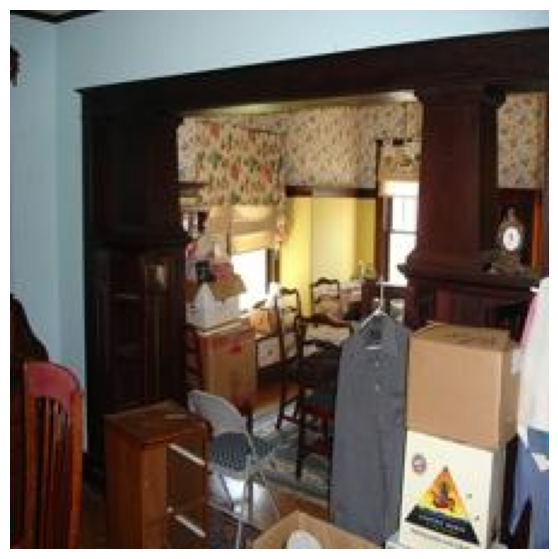

In [69]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1, figsize=(7, 7))

ax.imshow(image.permute(1, 2, 0))
ax.axis(False)

plt.show()

In [70]:
cells_with_object = []

for i, row in enumerate(target_vector):
    for j, col in enumerate(row):
        if col.any():
            cells_with_object.append((i, j))

cells_with_object

[(3, 4), (4, 3), (5, 0), (5, 2), (5, 4)]

In [77]:
obj_coords, class_labels = [], []

for i, j in cells_with_object:
    cell = target_vector[i][j]
    class_label = IDX_TO_CLASS[int(cell.argwhere()[0])]

    x, y = cell[20], cell[21]
    w, h = cell[22], cell[23]

    print(x, y, w, h, i, j)

    x = (cell[20] * CELL_SIZE) + (j * CELL_SIZE)
    y = (cell[21] * CELL_SIZE) + (i * CELL_SIZE)
    w = cell[22] * IMAGE_SIZE
    h = cell[23] * IMAGE_SIZE

    xmin = int(torch.round(x - w/2))
    ymin = int(torch.round(y - h/2))
    xmax = int(torch.round(x + w/2))
    ymax = int(torch.round(y + h/2))

    obj_coords.append((xmin, ymin, xmax, ymax))
    class_labels.append(class_label)

obj_coords, class_labels

tensor(0.1250) tensor(0.7812) tensor(0.0714) tensor(0.0893) 3 4
tensor(0.7500) tensor(0.5938) tensor(0.1071) tensor(0.2812) 4 3
tensor(0.5000) tensor(0.7812) tensor(0.1250) tensor(0.3482) 5 0
tensor(0.9375) tensor(0.9375) tensor(0.1741) tensor(0.2902) 5 2
tensor(0.0938) tensor(0.1250) tensor(0.1205) tensor(0.3393) 5 4


([(124, 111, 140, 131),
  (108, 116, 132, 178),
  (2, 146, 30, 224),
  (74, 158, 114, 222),
  (118, 126, 144, 202)],
 ['chair', 'chair', 'chair', 'chair', 'chair'])

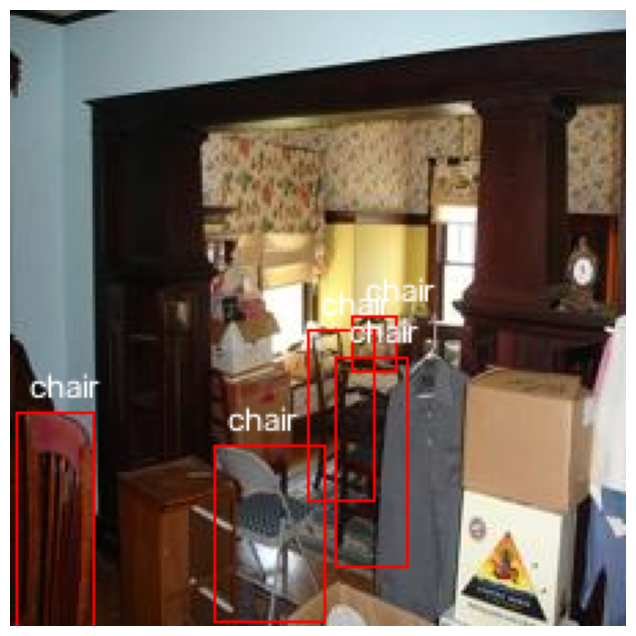

In [72]:
import bbox_visualizer as bbv

fig, ax = plt.subplots(1, figsize=(8, 8))

image = image.permute(1, 2, 0).numpy()

image = bbv.draw_multiple_rectangles(image, obj_coords, bbox_color=(255, 0, 0), thickness=1)
image = bbv.add_multiple_labels(image, class_labels, obj_coords, size=0.4, thickness=1, 
                                text_color=(255, 255, 255), draw_bg=False)

ax.imshow(image)
ax.axis(False)

plt.show()

In [ ]:
from torch.utils.data import DataLoader

